Animation stopped.


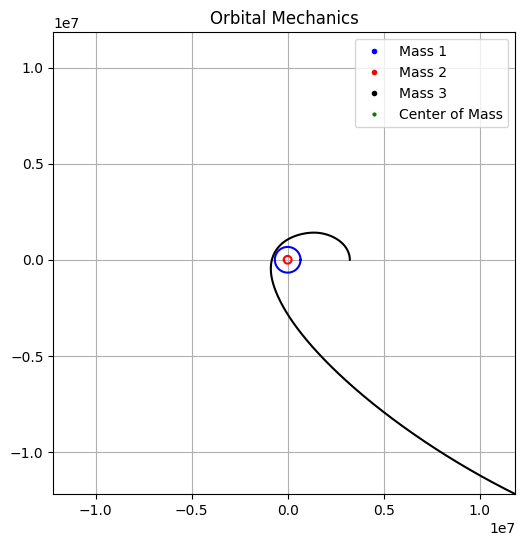

In [29]:
#Circural Three Body, one non-impacting

from numpy import linspace, sqrt, cbrt, pi, cos, sin, arctan
import matplotlib.pyplot as plt
from IPython import display
import ipywidgets as widgets
from ipywidgets import interact_manual

M1 = 9 * 10**30
M2 = 30 * 10**30
M3= 1 * 10**30
PeriodM = 0.1
PeriodM3= 1
NumberofMesurements = 60*65*24

G = 6.6743 * 10**-11
timeArray = linspace(0, PeriodM, NumberofMesurements)
timeStep=PeriodM/NumberofMesurements
M3PastX=[]
M3PastY=[]
M3XVelocity=0
M3YVelocity=0
M3XAcceleration=0
runLength=10**6

APrime = cbrt((G * (M1 + M2) * PeriodM**2) / (4 * pi**2))
M1A = APrime * M2 / (M1 + M2)
M2A = APrime * M1 / (M1 + M2)
omega = (2 * pi) / PeriodM

M1x, M1y = M1A * cos(omega * timeArray), M1A * sin(omega * timeArray)
M2x, M2y = M2A * cos(omega * timeArray+pi), M2A * sin(omega * timeArray+pi)

AM3 = cbrt((G * (M1 + M3) * PeriodM3**2) / (4 * pi**2))
M3A = AM3 * M1 / (M1 + M3)

M3YVelocity=sqrt(G*M1/M3A)

M3x = M1x[0]+AM3
M3y = M1y[0]

t = 0

for x in range(runLength):
    M1xT,M1yT=M1x[t],M1y[t]
    M2xT,M2yT=M2x[t],M2y[t]

    dx1, dy1 = M1xT - M3x, M1yT - M3y
    dist1 = sqrt(dx1**2 + dy1**2)
    force1 = G * M1 * M3 / dist1**2
    fx1 = force1 * dx1 / dist1
    fy1 = force1 * dy1 / dist1

    dx2, dy2 = M2xT - M3x, M2yT - M3y
    dist2 = sqrt(dx2**2 + dy2**2)
    force2 = G * M2 * M3 / dist2**2
    fx2 = force2 * dx2 / dist2
    fy2 = force2 * dy2 / dist2

    XForceTotal=fx1+fx2
    YForceTotal=fy1+fy2

    M3YAcceleration=YForceTotal/M3
    M3XAcceleration=XForceTotal/M3

    M3XVelocity+=M3XAcceleration*timeStep
    M3YVelocity+=M3YAcceleration*timeStep

    M3PastY.append(M3y)
    M3PastX.append(M3x)

    M3x+=M3XVelocity*timeStep
    M3y+=M3YVelocity*timeStep

    t=(t+1)%len(timeArray)

fig, ax = plt.subplots(figsize=(6, 6))

t1=0
t=0

M1Point, = ax.plot([], [], 'bo', markersize=3, label='Mass 1')
M2Point, = ax.plot([], [], 'ro', markersize=3, label='Mass 2')
M3Point, = ax.plot([], [], 'ko', markersize=3, label='Mass 3')
CenterOfMass, = ax.plot([], [], 'go', markersize=2, label='Center of Mass')

loops=0


minX1 = min(M1x)
maxX1 = max(M1x)
minY1 = min(M1y)
maxY1 = max(M1y)

minX2 = min(M2x)
maxX2 = max(M2x)
minY2 = min(M2y)
maxY2 = max(M2y)

minX3 = min(M3PastX)
maxX3 = max(M3PastX)
minY3 = min(M3PastY)
maxY3 = max(M3PastY)

Max= max([maxX3,maxY3,maxY1,maxX1,maxX2,maxY2])
Min= min([minX3,minY3,minY1,minX1,minX2,minY2])


ax.set_xlim(Min,Max)
ax.set_ylim(Min,Max)

ax.set_aspect('equal')
ax.grid(True)
ax.legend()

try:
    while True:
        M1xT,M1yT=M1x[t],M1y[t]
        M2xT,M2yT=M2x[t],M2y[t]
        M3x=M3PastX[t1]
        M3y=M3PastY[t1]

        M1Point.set_data([M1xT], [M1yT])
        M2Point.set_data([M2xT], [M2yT])
        M3Point.set_data([M3x],[M3y])

        CenterofMassX=(M1xT*M1+M2xT*M2)/(M1+M2)
        CenterofMassY=(M1yT*M1+M2yT*M2)/(M1+M2)

        CenterOfMass.set_data([CenterofMassX],[CenterofMassY])
        
        ax.set_title(f"Orbital Mechanics: Time {timeArray[t]+PeriodM*loops:.5f} Years")
        ax.legend()

        display.clear_output(wait=True)
        display.display(fig)

        t1+=100
        t+=100
        if t>=len(timeArray):
            t=1
            loops+=1

        if t1>=len(M3PastX):
            t=1
            t1=1
            loops=0
except KeyboardInterrupt:
    display.clear_output(wait=True)
    M1Point.set_data([Max*2], [Max*2])
    M2Point.set_data([Max*2], [Max*2])
    M3Point.set_data([Max*2],[Max*2])
    CenterOfMass.set_data([Max*2],[Max*2])

    ax.plot(M1x,M1y,c="blue")
    ax.plot(M2x,M2y,c="red")
    ax.plot(M3PastX,M3PastY,c='black')

    
    ax.set_title(f"Orbital Mechanics")
    ax.legend()

    print("Animation stopped.")